## Indicador de efectividad 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:

# Ruta al archivo (ajusta si está en otra ubicación)
file_path = 'base_datos_completa_NNA_TI_anon.xlsx'

# Verificar existencia
if not os.path.isfile(file_path):
    raise FileNotFoundError(f"Archivo no encontrado en el directorio actual: {file_path}")

# Intentar abrir con openpyxl; si falla, dejar que pandas elija
try:
    xls = pd.ExcelFile(file_path, engine='openpyxl')
except Exception:
    xls = pd.ExcelFile(file_path)

print("Hojas disponibles:", xls.sheet_names)
# Intentamos cargar la segunda hoja (sheet index 1). Si no existe, cargamos la primera.
sheet_to_load = 1
if sheet_to_load < len(xls.sheet_names):
    sheet_name = xls.sheet_names[sheet_to_load]
else:
    sheet_name = xls.sheet_names[0]

print(f"Cargando hoja: {sheet_name!r}")
# Cargar la hoja elegida
df = pd.read_excel(xls, sheet_name=sheet_name)
# Eliminar duplicados

df_clean = df.drop_duplicates()
print("Cargado DataFrame con shape:", df_clean.shape)


Hojas disponibles: ['variables', 'BD']
Cargando hoja: 'BD'
Cargado DataFrame con shape: (52783, 115)
Cargado DataFrame con shape: (52783, 115)


In [22]:
# Convertir la columna objetivo a binaria con comprobaciones
target_col = 'NNA DESVINCULADO DE LA ACTIVIDAD LABORAL'
if target_col not in df_clean.columns:
    raise KeyError(f"La columna esperada para el target no se encontró: {target_col}")

# Normalizar valores a cadena y quitar espacios
vals = df_clean[target_col].astype(str).str.strip().str.lower()

# Mapear varias formas de 'si'/'no'
mapping = {
    'si': 1, 'sí': 1, 's': 1, 'si ': 1, 'si.': 1,
    'no': 0, 'n': 0, 'no ': 0
}

def map_diseng(x):
    if x in mapping:
        return mapping[x]
    # Intentar interpretar numérico
    try:
        if float(x) == 1:
            return 1
        if float(x) == 0:
            return 0
    except Exception:
        pass
    # Valores desconocidos como NaN
    return pd.NA

# Aplicar y reportar
df_clean['disengaged'] = vals.apply(map_diseng)
num_missing_target = df_clean['disengaged'].isna().sum()
print(f"Target mapeado. Valores desconocidos/NA: {num_missing_target}")
# Si hay muchos NA, mostrar ejemplos
if num_missing_target > 0:
    print("Ejemplos de valores no mapeados:")
    print(df_clean.loc[df_clean['disengaged'].isna(), target_col].unique()[:10])


Target mapeado. Valores desconocidos/NA: 12090
Ejemplos de valores no mapeados:
[99999 'NO APLICA']


/var/folders/_b/fjlvpyhj71q1cth5f5r88rsh0000gn/T/ipykernel_9395/2153470518.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['disengaged'] = vals.apply(map_diseng)


In [23]:
# Revisión de cambio en la nueva variable disengaged, "desviculados" = 1, "no desvinculados" = 0
print(f"Target variable distribution after cleaning:")
print(df_clean['disengaged'].value_counts())

Target variable distribution after cleaning:
disengaged
1    33413
0     7280
Name: count, dtype: int64


In [24]:
# Limpieza de la columna EDAD con comprobaciones y manejo de outliers
age_col = 'EDAD'
if age_col not in df_clean.columns:
    raise KeyError(f"No se encontró la columna de edad: {age_col}")

# Reemplazar valores sentinela comunes (ej. 99999) y strings vacíos
# Convertir a numérico forzando NaN en valores inválidos

df_clean[age_col] = pd.to_numeric(df_clean[age_col], errors='coerce')

# Detectar valores atípicos extremadamente grandes
sentinel_threshold = 120
invalid_mask = (df_clean[age_col].isna()) | (df_clean[age_col] > sentinel_threshold) | (df_clean[age_col] < 0)
num_invalid = invalid_mask.sum()
print(f"Valores de edad inválidos o fuera de rango: {num_invalid}")

# Rellenar con la mediana de las edades válidas
median_age = int(df_clean.loc[~invalid_mask, age_col].median()) if (~invalid_mask).any() else 0
print(f"Mediana calculada para EDAD: {median_age}")

df_clean.loc[invalid_mask, age_col] = median_age

df_clean[age_col] = df_clean[age_col].astype(int)
print("Edad media final:", df_clean[age_col].mean())


Valores de edad inválidos o fuera de rango: 21038
Mediana calculada para EDAD: 9
Edad media final: 8.935774775969536


/var/folders/_b/fjlvpyhj71q1cth5f5r88rsh0000gn/T/ipykernel_9395/3770384958.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[age_col] = pd.to_numeric(df_clean[age_col], errors='coerce')
/var/folders/_b/fjlvpyhj71q1cth5f5r88rsh0000gn/T/ipykernel_9395/3770384958.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[age_col] = df_clean[age_col].astype(int)


In [25]:
# INDICATOR 1: Overall Success Rate by Different Dimensions
print("=== Indicadores de Efectividad de la Intervención ===\n")

# Overall success rate
overall_success = df_clean['disengaged'].mean() * 100
print(f"1. Tasa de Éxito General: {overall_success:.1f}%")

# Success by locality
locality_success = df_clean.groupby('Localidad_fic').agg({
    'disengaged': ['mean', 'count']
}).round(3)
locality_success.columns = ['success_rate', 'intervention_count']
locality_success['success_rate_pct'] = (locality_success['success_rate'] * 100).round(1)

print("\n2. Tasa de Éxito por Localidad:")
print(locality_success.sort_values('success_rate', ascending=False).head(10))

# Success by intervention type
intervention_success = df_clean.groupby('TIPO INTERVENCIÓN').agg({
    'disengaged': ['mean', 'count']
}).round(3)
intervention_success.columns = ['success_rate', 'intervention_count']
intervention_success['success_rate_pct'] = (intervention_success['success_rate'] * 100).round(1)


=== Indicadores de Efectividad de la Intervención ===

1. Tasa de Éxito General: 82.1%

2. Tasa de Éxito por Localidad:
               success_rate  intervention_count success_rate_pct
Localidad_fic                                                   
Chapinero          0.941176                  68        94.117647
Suba               0.931014                3305        93.101362
Usme               0.926132                2870         92.61324
Engativá           0.893207                2753        89.320741
Barrios Unidos     0.890704                1775        89.070423
Teusaquillo            0.88                 175             88.0
Usaquén            0.864116                1516        86.411609
Fontibón           0.864066                 846        86.406619
Tunjuelito         0.828552                1464        82.855191
Bosa               0.808807                4383        80.880675


## 2. Indicador de perfil de riesgo demográfico

In [26]:
# INDICATOR 2: Demographic Risk Profiles
print("\n=== PERFILES DE RIESGO DEMOGRÁFICO ===\n")

# Create age groups
df_clean['age_group'] = pd.cut(df_clean['EDAD'], 
                               bins=[0, 12, 15, 18, 100], 
                               labels=['Niños (0-12)', 'Adolescentes Tempranos (13-15)', 'Adolescentes (16-18)', 'Adultos (18+)'])

# Success rate by age group
age_success = df_clean.groupby('age_group').agg({
    'disengaged': ['mean', 'count']
}).round(3)
age_success.columns = ['success_rate', 'intervention_count']
age_success['success_rate_pct'] = (age_success['success_rate'] * 100).round(1)

print("1. Tasa de Éxito por Grupo de Edad:")
print(age_success)

# Risk indicator: Which groups need more attention?
age_success['risk_level'] = pd.cut(age_success['success_rate'], 
                                   bins=[0, 0.3, 0.6, 1],
                                   labels=['Alto', 'Medio', 'Bajo'])

print("\n2. Nivel de Riesgo por Grupos de Edad:")
print(age_success[['success_rate_pct', 'risk_level']])


=== PERFILES DE RIESGO DEMOGRÁFICO ===

1. Tasa de Éxito por Grupo de Edad:
                               success_rate  intervention_count  \
age_group                                                         
Niños (0-12)                       0.830624               34320   
Adolescentes Tempranos (13-15)     0.815884                3878   
Adolescentes (16-18)               0.716586                1863   
Adultos (18+)                           NaN                   0   

                               success_rate_pct  
age_group                                        
Niños (0-12)                          83.062354  
Adolescentes Tempranos (13-15)        81.588448  
Adolescentes (16-18)                  71.658615  
Adultos (18+)                               NaN  

2. Nivel de Riesgo por Grupos de Edad:
                               success_rate_pct risk_level
age_group                                                 
Niños (0-12)                          83.062354       Bajo
Ado

/var/folders/_b/fjlvpyhj71q1cth5f5r88rsh0000gn/T/ipykernel_9395/2875068803.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['age_group'] = pd.cut(df_clean['EDAD'],
/var/folders/_b/fjlvpyhj71q1cth5f5r88rsh0000gn/T/ipykernel_9395/2875068803.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_success = df_clean.groupby('age_group').agg({


## 3. Indicador de tendencias temporales 

In [27]:
# INDICATOR 3: Temporal Trends and Seasonality
print("\n=== Tendencias Temporales ===\n")

# Convert dates
df_clean['Fecha_intervencion'] = pd.to_datetime(df_clean['Fecha_intervencion'])
df_clean['year'] = df_clean['Fecha_intervencion'].dt.year
df_clean['month'] = df_clean['Fecha_intervencion'].dt.month
df_clean['quarter'] = df_clean['Fecha_intervencion'].dt.quarter

# Success rate over time
yearly_trend = df_clean.groupby('year').agg({
    'disengaged': ['mean', 'count']
}).round(3)
yearly_trend.columns = ['success_rate', 'intervention_count']

print("1. Tendencias Anuales:")
print(yearly_trend)

# Monthly seasonality
monthly_pattern = df_clean.groupby('month').agg({
    'disengaged': 'mean'
}).round(3)
monthly_pattern['success_rate_pct'] = (monthly_pattern['disengaged'] * 100).round(1)

print("\n2. Patrones Mensuales:")
print(monthly_pattern[['success_rate_pct']])


=== Tendencias Temporales ===

1. Tendencias Anuales:
     success_rate  intervention_count
year                                 
2021     0.859372               10254
2022     0.839526                5652
2023     0.818726               12859
2024     0.783868               10637
2025     0.766847                1291

2. Patrones Mensuales:
      success_rate_pct
month                 
1            80.110243
2             83.38408
3             82.11326
4             82.39864
5             82.50851
6             83.02653
7            83.631436
8             80.93823
9            84.756899
10           78.811293
11           84.809676
12           79.946761


/var/folders/_b/fjlvpyhj71q1cth5f5r88rsh0000gn/T/ipykernel_9395/3243755518.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Fecha_intervencion'] = pd.to_datetime(df_clean['Fecha_intervencion'])
/var/folders/_b/fjlvpyhj71q1cth5f5r88rsh0000gn/T/ipykernel_9395/3243755518.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['year'] = df_clean['Fecha_intervencion'].dt.year
/var/folders/_b/fjlvpyhj71q1cth5f5r88rsh0000gn/T/ipykernel_9395/3243755518.py:7: SettingWithCopyWarning: 
A value is try

## 4. Indicador de punto de acceso geográfico

In [31]:
# INDICATOR 5: Geographic Hotspots
print("\n=== GEOGRAPHIC HOTSPOTS ===\n")

# Combine locality and network for geographic analysis
geo_analysis = df_clean.groupby(['Localidad_fic', 'Red_fic']).agg({
    'disengaged': ['mean', 'count'],
    'EDAD': 'mean'
}).round(3)
geo_analysis.columns = ['success_rate', 'case_count', 'average_age']

geo_analysis['success_rate_pct'] = (geo_analysis['success_rate'] * 100).round(1)
geo_analysis['average_age'] = geo_analysis['average_age'].round(1)

# Identify priority areas (high case count, low success)
geo_analysis['priority_score'] = (geo_analysis['case_count'] * (1 - geo_analysis['success_rate'])).round(1)

print("Geographic Priority Areas (High case load, Low success):")
priority_areas = geo_analysis.sort_values('priority_score', ascending=False).head(10)
print(priority_areas[['case_count', 'success_rate_pct', 'average_age', 'priority_score']])


=== GEOGRAPHIC HOTSPOTS ===

Geographic Priority Areas (High case load, Low success):
                                   case_count success_rate_pct  average_age  \
Localidad_fic      Red_fic                                                    
Ciudad Bolívar     Sur                   3804        74.263933          9.0   
Bosa               Suroccidente          2839        79.957732          9.2   
Kennedy            Suroccidente          2815        80.106572          9.4   
Rafael Uribe Uribe Centro Oriente        1475         64.40678          8.5   
San Cristóbal      Centro Oriente        1362        66.886931          9.1   
Los Mártires       Centro Oriente        1640        73.231707          8.3   
Ciudad Bolívar     3                     1900        81.842105          8.9   
Santa fe           Centro Oriente        1384        77.601156          8.0   
Bosa               4                     1544         82.57772          9.3   
Kennedy            4                     133

## 5. Indicador compuesto de salud del programa

In [32]:
# INDICATOR 6: Composite Program Health Score
print("\n=== COMPOSITE PROGRAM HEALTH INDICATOR ===\n")

def calculate_program_health(df):
    metrics = {}
    
    # Success rate (weight: 40%)
    metrics['success_rate'] = df['disengaged'].mean()
    
    # Case volume (weight: 20%)
    total_cases = len(df)
    metrics['case_volume_score'] = min(total_cases / 1000, 1.0)  # Normalize to 0-1
    
    # Age coverage (weight: 20%) - younger children are priority
    young_cases = len(df[df['EDAD'] < 16])
    metrics['age_coverage_score'] = young_cases / total_cases if total_cases > 0 else 0
    
    # Geographic diversity (weight: 20%)
    unique_localities = df['Localidad_fic'].nunique()
    metrics['diversity_score'] = min(unique_localities / 10, 1.0)
    
    # Calculate composite score
    weights = [0.4, 0.2, 0.2, 0.2]
    composite_score = sum(metric * weight for metric, weight in zip(metrics.values(), weights))
    
    return composite_score, metrics

program_health, health_metrics = calculate_program_health(df_clean)

print(f"Program Health Score: {program_health:.3f}")
print("\nComponent Metrics:")
for metric, value in health_metrics.items():
    print(f"  {metric}: {value:.3f}")

# Health interpretation
if program_health >= 0.7:
    health_status = "EXCELLENT"
elif program_health >= 0.5:
    health_status = "GOOD"
elif program_health >= 0.3:
    health_status = "NEEDS IMPROVEMENT"
else:
    health_status = "CRITICAL"

print(f"\nProgram Status: {health_status}")


=== COMPOSITE PROGRAM HEALTH INDICATOR ===

Program Health Score: 0.918

Component Metrics:
  success_rate: 0.821
  case_volume_score: 1.000
  age_coverage_score: 0.948
  diversity_score: 1.000

Program Status: EXCELLENT


## Visualizaciones

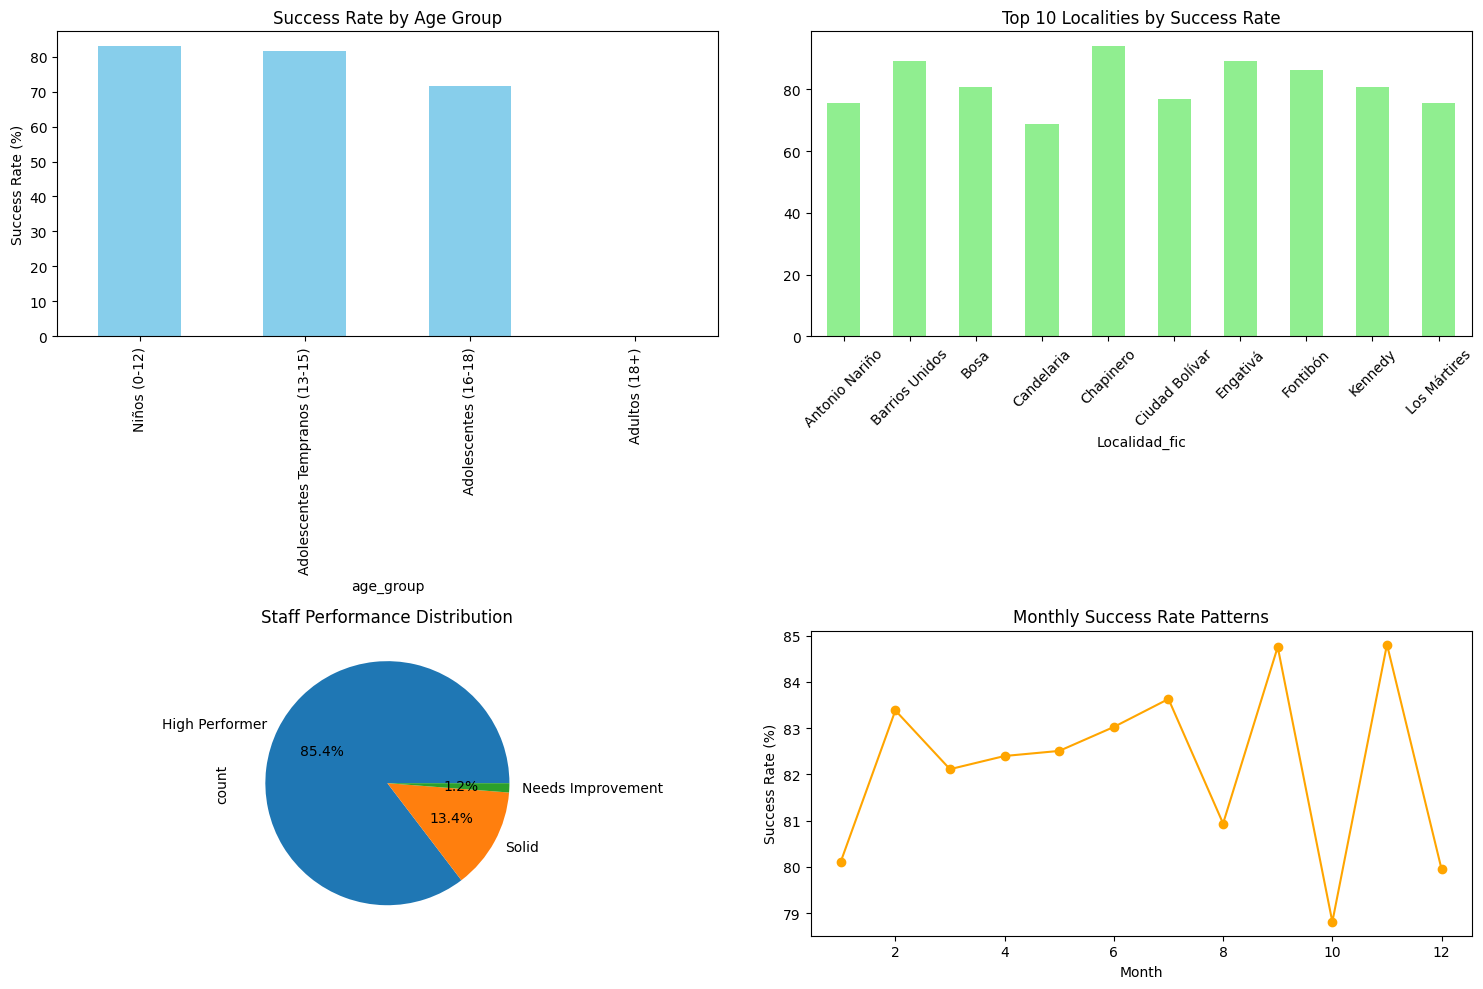


=== KEY INDICATORS SUMMARY ===
overall_success_rate: 82.10994519942004
program_health_score: 0.9180765956812602
high_risk_age_group: None
top_performing_locality: Antonio Nariño
total_interventions: 52783


In [33]:
# Create visualization dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Success by Age Group
age_success['success_rate_pct'].plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Success Rate by Age Group')
axes[0,0].set_ylabel('Success Rate (%)')

# Plot 2: Top performing localities
locality_success['success_rate_pct'].head(10).plot(kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Top 10 Localities by Success Rate')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Staff performance distribution
staff_performance['performance_tier'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%')
axes[1,0].set_title('Staff Performance Distribution')

# Plot 4: Monthly trends
monthly_pattern['success_rate_pct'].plot(kind='line', ax=axes[1,1], marker='o', color='orange')
axes[1,1].set_title('Monthly Success Rate Patterns')
axes[1,1].set_ylabel('Success Rate (%)')
axes[1,1].set_xlabel('Month')

plt.tight_layout()
plt.show()

# Export indicators to CSV
indicators_summary = {
    'overall_success_rate': overall_success,
    'program_health_score': program_health,
    'high_risk_age_group': age_success[age_success['risk_level'] == 'High Risk'].index[0] if any(age_success['risk_level'] == 'High Risk') else 'None',
    'top_performing_locality': locality_success.index[0],
    'total_interventions': len(df_clean)
}

print("\n=== KEY INDICATORS SUMMARY ===")
for indicator, value in indicators_summary.items():
    print(f"{indicator}: {value}")